# Hard packed-food scene vs. the best generalized U-Net

This notebook creates one reproducible stress-test scene. It forces all eight food objects onto the plate, uses compact object sizes, arranges the objects in a deliberately crowded cluster, keeps the randomized color/camera/lighting conditions, and evaluates `General_Attempt_Using_2nd_Overfit/best_UNet.pt`.

The model predicts one heatmap containing multiple food-center peaks. The final cells visualize those peaks and measure their distance from the nearest ground-truth center.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import mujoco
import numpy as np
import torch
import torch.nn.functional as F
from scipy.ndimage import maximum_filter
from scipy.optimize import linear_sum_assignment


def find_environment_directory():
    current_directory = Path.cwd().resolve()
    candidates = [
        current_directory,
        current_directory.parent,
        current_directory / "CODE" / "Enviornment",
        *[parent / "CODE" / "Enviornment" for parent in current_directory.parents],
    ]
    for candidate in candidates:
        if (candidate / "enviornment.py").is_file() and (candidate / "xml_models" / "world.xml").is_file():
            return candidate
    raise RuntimeError("Could not find CODE/Enviornment from the current notebook directory")


ENVIRONMENT_DIRECTORY = find_environment_directory()
if str(ENVIRONMENT_DIRECTORY) not in sys.path:
    sys.path.insert(0, str(ENVIRONMENT_DIRECTORY))

from Model.UNet.unet import UNet
from Model.UNet.tmp.UNET_MODEL_OVERFIT_2ND_ROUND.UNetV2Constants import UNetV2Constants
from enviornment import Enviornment
from enviornment_randomizer import Enviornment_Randomizer
from randomization_constants import Randomization_Constants

WORLD_XML_FILE = ENVIRONMENT_DIRECTORY / "xml_models" / "world.xml"
BEST_CHECKPOINT_FILE = (
    ENVIRONMENT_DIRECTORY
    / "Model"
    / "UNet"
    / "tmp"
    / "General_Attempt_Using_2nd_Overfit"
    / "best_UNet.pt"
)
assert BEST_CHECKPOINT_FILE.is_file(), f"Best generalized checkpoint not found: {BEST_CHECKPOINT_FILE}"

print(f"Environment directory: {ENVIRONMENT_DIRECTORY}")
print(f"Checkpoint: {BEST_CHECKPOINT_FILE}")

Environment directory: /Users/aadibhatia/self-feeder-env/CODE/Enviornment
Checkpoint: /Users/aadibhatia/self-feeder-env/CODE/Enviornment/Model/UNet/tmp/General_Attempt_Using_2nd_Overfit/best_UNet.pt


## Construct the packed scene

`HARD_SCENE_SEED` controls the randomized colors, rotations, camera pose, and lighting. The XY locations below are fixed so all eight objects remain densely packed for a fair, repeatable stress test.

In [2]:
HARD_SCENE_SEED = 2_607_260

randomization_constants = Randomization_Constants()
model_constants = UNetV2Constants()
enviornment_randomizer = Enviornment_Randomizer()

# Force every available food slot into the scene.
randomization_constants.minimum_objects = randomization_constants.total_food_slots

# Keep eight objects physically plausible on the plate while still making their
# silhouettes and centers close enough to be a difficult localization case.
randomization_constants.primitive_size_ranges = {
    "sphere": [[0.004, 0.007]],
    "capsule": [[0.004, 0.006], [0.014, 0.020]],
    "ellipsoid": [[0.014, 0.018], [0.016, 0.021], [0.004, 0.007]],
    "cylinder": [[0.014, 0.018], [0.004, 0.008]],
    "box": [[0.012, 0.017], [0.010, 0.015], [0.005, 0.010]],
}
randomization_constants.object_clearance = 0.0005

env = Enviornment(
    xml_file=str(WORLD_XML_FILE),
    Enviornment_Randomizer=enviornment_randomizer,
    Randomization_Constants=randomization_constants,
    Model_Constants=model_constants,
    starting_seed=HARD_SCENE_SEED,
)
env.new_scene(seed=HARD_SCENE_SEED)

plate_xy = env.model.body(randomization_constants.plate_body_name).pos[:2].copy()
packed_offsets = np.array([
    [-0.030, -0.026],
    [ 0.000, -0.031],
    [ 0.030, -0.025],
    [-0.037,  0.004],
    [-0.012,  0.001],
    [ 0.014,  0.004],
    [ 0.039,  0.009],
    [-0.008,  0.033],
])
packed_angles = np.deg2rad([15, -35, 70, 105, -10, 48, -78, 130])

for body_name, xy_offset, angle in zip(
    randomization_constants.all_food_body_names,
    packed_offsets,
    packed_angles,
):
    body = env.model.body(body_name)
    body.pos[:2] = plate_xy + xy_offset
    body.pos[2] = randomization_constants.in_scene_z_coordinate
    body.quat[:] = [np.cos(angle / 2), 0.0, 0.0, np.sin(angle / 2)]

env.model, env.data = enviornment_randomizer.reset(env.model, env.data)
env.calculate_camera_matrix()

active_food_count = env.get_number_of_active_food_objects()
assert active_food_count == randomization_constants.total_food_slots
assert np.all(np.linalg.norm(packed_offsets, axis=1) < randomization_constants.plate_radius)

print(f"Hard-scene seed: {HARD_SCENE_SEED}")
print(f"Active food objects: {active_food_count}/{randomization_constants.total_food_slots}")
print("Packed body centers (world XY):")
for body_name in randomization_constants.all_food_body_names:
    body_position = env.model.body(body_name).pos
    print(f"  {body_name:28s} ({body_position[0]: .4f}, {body_position[1]: .4f})")

Hard-scene seed: 2607260
Active food objects: 8/8
Packed body centers (world XY):
  full_slice_instance          (-0.0300, -0.0260)
  deformed_slice_instance      ( 0.0000, -0.0310)
  rod_instance                 ( 0.0300, -0.0250)
  block_instance               (-0.0370,  0.0040)
  full_slice_instance_2        (-0.0120,  0.0010)
  deformed_slice_instance_2    ( 0.0140,  0.0040)
  rod_instance_2               ( 0.0390,  0.0090)
  block_instance_2             (-0.0080,  0.0330)


## Run `best_UNet.pt`

In [3]:
rgb_observation = env.observation()
target_heatmap = env.get_target_heatmap()

model = UNet(
    in_channels=3,
    num_classes=1,
    checkpoint_dir=str(BEST_CHECKPOINT_FILE.parent),
    learning_rate=model_constants.learning_rate,
)
model.load_state_dict(
    torch.load(BEST_CHECKPOINT_FILE, map_location=model.device, weights_only=True)
)
model.eval()

model_input = (
    torch.from_numpy(rgb_observation)
    .permute(2, 0, 1)
    .unsqueeze(0)
    .float()
    / 255.0
)
model_input = F.interpolate(
    model_input,
    size=(model_constants.input_y_dim, model_constants.input_x_dim),
    mode="bilinear",
    align_corners=False,
).to(model.device)

with torch.no_grad():
    prediction_logits = model(model_input)
    predicted_heatmap = torch.sigmoid(prediction_logits)[0, 0].cpu().numpy()

assert predicted_heatmap.shape == target_heatmap.shape
assert np.isfinite(predicted_heatmap).all()

print(f"Model device: {model.device}")
print(f"RGB shape: {rgb_observation.shape}")
print(f"Prediction shape: {predicted_heatmap.shape}")
print(f"Prediction range: {predicted_heatmap.min():.6f} to {predicted_heatmap.max():.6f}")

Created UNet on: mps
Model device: mps
RGB shape: (1080, 1920, 3)
Prediction shape: (144, 256)
Prediction range: 0.000000 to 0.849811


## Visualize predictions and quantify localization

We select at most eight well-separated local maxima with at least 5% predicted probability. The Hungarian assignment then matches predictions one-to-one with distinct true food centers. Distances are measured in the model's 256×144 heatmap pixels.

Ground-truth centers found: 8
Predicted peaks selected: 7
Detection threshold: 5%
Unmatched ground-truth centers: 1
Peak 1: (x=103, y= 61), probability=0.8498, assigned target distance=1.41px
Peak 2: (x= 88, y= 80), probability=0.3851, assigned target distance=3.61px
Peak 3: (x=124, y= 83), probability=0.2943, assigned target distance=10.30px
Peak 4: (x=107, y=100), probability=0.2575, assigned target distance=18.38px
Peak 5: (x= 88, y= 96), probability=0.2116, assigned target distance=2.83px
Peak 6: (x= 99, y= 78), probability=0.2051, assigned target distance=1.00px
Peak 7: (x= 96, y= 96), probability=0.2005, assigned target distance=11.05px
Mean matched distance: 6.94px
Worst matched distance: 18.38px


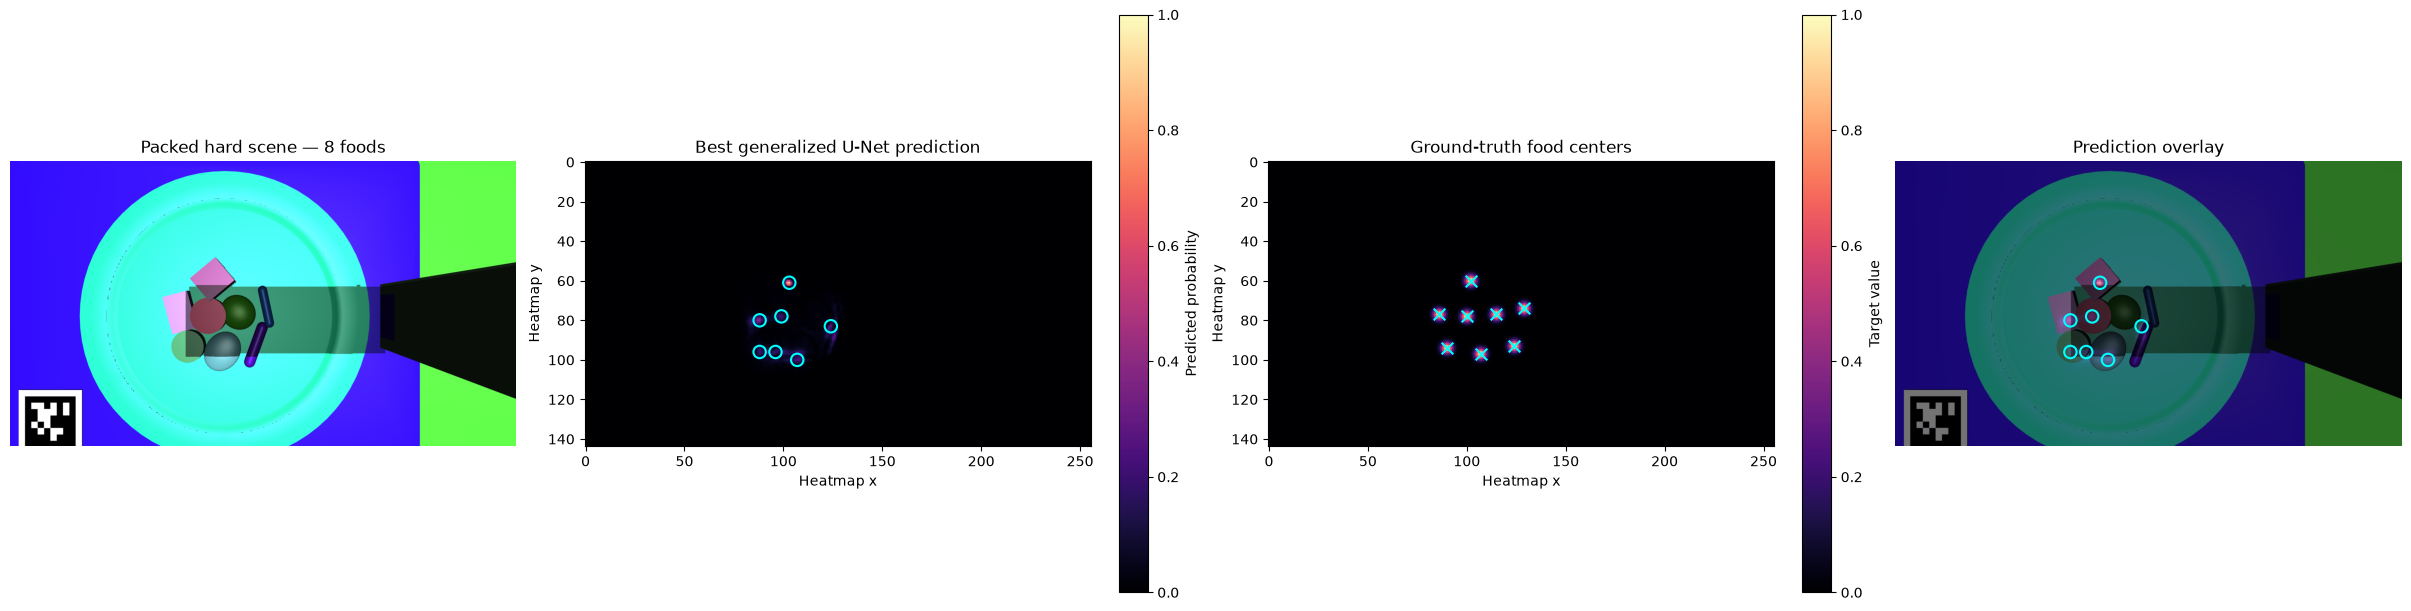

In [4]:
MINIMUM_PEAK_PROBABILITY = 0.05


def select_separated_peaks(
    heatmap,
    number_of_peaks,
    minimum_distance=5,
    minimum_probability=MINIMUM_PEAK_PROBABILITY,
):
    local_maximum_mask = heatmap == maximum_filter(
        heatmap,
        size=2 * minimum_distance + 1,
        mode="nearest",
    )
    candidate_mask = local_maximum_mask & (heatmap >= minimum_probability)
    candidate_coordinates = np.argwhere(candidate_mask)
    candidate_scores = heatmap[candidate_mask]
    score_order = np.argsort(candidate_scores)[::-1]
    return candidate_coordinates[score_order[:number_of_peaks]]


target_centers_yx = np.argwhere(np.isclose(target_heatmap, 1.0))
predicted_peaks_yx = select_separated_peaks(
    predicted_heatmap,
    number_of_peaks=active_food_count,
)

pairwise_distances = np.linalg.norm(
    predicted_peaks_yx[:, None, :] - target_centers_yx[None, :, :],
    axis=2,
)
predicted_indices, target_indices = linear_sum_assignment(pairwise_distances)
matched_distances = pairwise_distances[predicted_indices, target_indices]
matched_target_by_prediction = dict(zip(predicted_indices, target_indices))

print(f"Ground-truth centers found: {len(target_centers_yx)}")
print(f"Predicted peaks selected: {len(predicted_peaks_yx)}")
print(f"Detection threshold: {MINIMUM_PEAK_PROBABILITY:.0%}")
print(f"Unmatched ground-truth centers: {len(target_centers_yx) - len(target_indices)}")
for predicted_index, predicted_yx in enumerate(predicted_peaks_yx):
    peak_number = predicted_index + 1
    y, x = predicted_yx
    target_index = matched_target_by_prediction[predicted_index]
    distance = pairwise_distances[predicted_index, target_index]
    print(
        f"Peak {peak_number}: (x={x:3d}, y={y:3d}), "
        f"probability={predicted_heatmap[y, x]:.4f}, "
        f"assigned target distance={distance:.2f}px"
    )
print(f"Mean matched distance: {matched_distances.mean():.2f}px")
print(f"Worst matched distance: {matched_distances.max():.2f}px")

observation_height, observation_width = rgb_observation.shape[:2]
heatmap_height, heatmap_width = predicted_heatmap.shape

fig, axes = plt.subplots(1, 4, figsize=(24, 6), constrained_layout=True)

axes[0].imshow(rgb_observation)
axes[0].set_title(f"Packed hard scene — {active_food_count} foods")
axes[0].axis("off")

prediction_image = axes[1].imshow(predicted_heatmap, cmap="magma", vmin=0.0, vmax=1.0)
axes[1].scatter(
    predicted_peaks_yx[:, 1],
    predicted_peaks_yx[:, 0],
    facecolors="none",
    edgecolors="cyan",
    s=80,
    linewidths=1.5,
)
axes[1].set_title("Best generalized U-Net prediction")
axes[1].set_xlabel("Heatmap x")
axes[1].set_ylabel("Heatmap y")
fig.colorbar(prediction_image, ax=axes[1], label="Predicted probability")

target_image = axes[2].imshow(target_heatmap, cmap="magma", vmin=0.0, vmax=1.0)
axes[2].scatter(
    target_centers_yx[:, 1],
    target_centers_yx[:, 0],
    c="cyan",
    marker="x",
    s=70,
)
axes[2].set_title("Ground-truth food centers")
axes[2].set_xlabel("Heatmap x")
axes[2].set_ylabel("Heatmap y")
fig.colorbar(target_image, ax=axes[2], label="Target value")

axes[3].imshow(rgb_observation)
axes[3].imshow(
    predicted_heatmap,
    cmap="magma",
    alpha=0.55,
    vmin=0.0,
    vmax=1.0,
    extent=(0, observation_width, observation_height, 0),
)
axes[3].scatter(
    (predicted_peaks_yx[:, 1] + 0.5) * observation_width / heatmap_width,
    (predicted_peaks_yx[:, 0] + 0.5) * observation_height / heatmap_height,
    facecolors="none",
    edgecolors="cyan",
    s=80,
    linewidths=1.5,
)
axes[3].set_title("Prediction overlay")
axes[3].axis("off")

plt.show()